# Task 3: Heart Disease Prediction
Objective:
Build a model to predict whether a person is at risk of heart disease based on their health data.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score,confusion_matrix

print('All libraries imported successfully!')

All libraries imported successfully!


In [3]:
# Load the dataset 
df = pd.read_csv("I:\DeveloperHC_Intern_AI(ML)intership\HeartDiseaseTrain-Test.csv")
print("First 3 rows of the dataset:")
print(df.head(3))

First 3 rows of the dataset:
   age   sex chest_pain_type  resting_blood_pressure  cholestoral  \
0   52  Male  Typical angina                     125          212   
1   53  Male  Typical angina                     140          203   
2   70  Male  Typical angina                     145          174   

      fasting_blood_sugar               rest_ecg  Max_heart_rate  \
0    Lower than 120 mg/ml  ST-T wave abnormality             168   
1  Greater than 120 mg/ml                 Normal             155   
2    Lower than 120 mg/ml  ST-T wave abnormality             125   

  exercise_induced_angina  oldpeak        slope vessels_colored_by_flourosopy  \
0                      No      1.0  Downsloping                           Two   
1                     Yes      3.1    Upsloping                          Zero   
2                     Yes      2.6    Upsloping                          Zero   

         thalassemia  target  
0  Reversable Defect       0  
1  Reversable Defect       0  
2  

In [4]:
df.drop(columns=['fasting_blood_sugar', 'rest_ecg'], inplace=True)

In [5]:
# df.head(3)

In [6]:
print(f"Dataset Shape: {df.shape}")
print("\nDataset all columns:")
print(df.columns.tolist())

Dataset Shape: (1025, 12)

Dataset all columns:
['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholestoral', 'Max_heart_rate', 'exercise_induced_angina', 'oldpeak', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia', 'target']


In [7]:
print("Dataset info")
print(df.info())


Dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   Max_heart_rate                 1025 non-null   int64  
 6   exercise_induced_angina        1025 non-null   object 
 7   oldpeak                        1025 non-null   float64
 8   slope                          1025 non-null   object 
 9   vessels_colored_by_flourosopy  1025 non-null   object 
 10  thalassemia                    1025 non-null   object 
 11  target                         1025 non-null   int64  
dtypes: float64(1), int64(5), object(6)


In [8]:
print("Dataset Summery Statistics")
print(df.describe())

Dataset Summery Statistics
               age  resting_blood_pressure  cholestoral  Max_heart_rate  \
count  1025.000000             1025.000000   1025.00000     1025.000000   
mean     54.434146              131.611707    246.00000      149.114146   
std       9.072290               17.516718     51.59251       23.005724   
min      29.000000               94.000000    126.00000       71.000000   
25%      48.000000              120.000000    211.00000      132.000000   
50%      56.000000              130.000000    240.00000      152.000000   
75%      61.000000              140.000000    275.00000      166.000000   
max      77.000000              200.000000    564.00000      202.000000   

           oldpeak       target  
count  1025.000000  1025.000000  
mean      1.071512     0.513171  
std       1.175053     0.500070  
min       0.000000     0.000000  
25%       0.000000     0.000000  
50%       0.800000     1.000000  
75%       1.800000     1.000000  
max       6.200000     1.

## Check Null values

In [9]:
df.isnull().sum()*100
#  there has no null values in our dataset 

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

### label ecoding of sex  columns

In [10]:
df["sex"].unique()

array(['Male', 'Female'], dtype=object)

In [11]:
le_se=LabelEncoder()
le_se.fit(df["sex"])

LabelEncoder()

In [12]:
df["sex"]=le_se.transform(df["sex"])

In [13]:
df["sex"].head(5)

0    1
1    1
2    1
3    1
4    0
Name: sex, dtype: int32

### label ecoding of chest_pain_type  columns

In [14]:
df["chest_pain_type"].unique()

array(['Typical angina', 'Atypical angina', 'Non-anginal pain',
       'Asymptomatic'], dtype=object)

In [15]:
le_chest=LabelEncoder()
df["chest_pain_type"]=le_chest.fit_transform(df["chest_pain_type"])

In [16]:
df["chest_pain_type"].head(5)

0    3
1    3
2    3
3    3
4    3
Name: chest_pain_type, dtype: int32

### label ecoding of exercise_induced_angina  columns

In [17]:
df["exercise_induced_angina"].unique()

array(['No', 'Yes'], dtype=object)

In [18]:
le_exercise=LabelEncoder()
df["exercise_induced_angina"]=le_exercise.fit_transform(df["exercise_induced_angina"])

### label ecoding of slope  columns

In [19]:
df["slope"].unique()

array(['Downsloping', 'Upsloping', 'Flat'], dtype=object)

In [20]:
le_slope=LabelEncoder()
df["slope"]=le_slope.fit_transform(df["slope"])

 ### label ecoding of vessels_colored_by_flourosopy columns

In [21]:
df["vessels_colored_by_flourosopy"].unique()

array(['Two', 'Zero', 'One', 'Three', 'Four'], dtype=object)

In [22]:
le_vessels=LabelEncoder()
df["vessels_colored_by_flourosopy"]=le_vessels.fit_transform(df["vessels_colored_by_flourosopy"])

### label ecoding of thalassemia columns 

In [23]:
df["thalassemia"].unique()

array(['Reversable Defect', 'Fixed Defect', 'Normal', 'No'], dtype=object)

In [24]:
le_thal=LabelEncoder()
df["thalassemia"]=le_thal.fit_transform(df["thalassemia"])

In [25]:
# After label encoding Dateset view
df.head(3)

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,1,3,125,212,168,0,1.0,0,3,3,0
1,53,1,3,140,203,155,1,3.1,2,4,3,0
2,70,1,3,145,174,125,1,2.6,2,4,3,0


In [26]:
X=df.iloc[:,:-1]
y=df["target"]

## Scale all dataset 

In [27]:
scale =StandardScaler()
scale_val=scale.fit_transform(X)

In [28]:
X=pd.DataFrame(scale_val,columns=X.columns)

In [29]:
X.head(3)

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia
0,-0.268437,0.661504,0.864114,-0.377636,-0.659332,0.821321,-0.712287,-0.060888,-0.995433,-0.002264,1.15588
1,-0.158157,0.661504,0.864114,0.479107,-0.833861,0.255968,1.403928,1.727137,2.243675,0.771279,1.15588
2,1.716595,0.661504,0.864114,0.764688,-1.396233,-1.048692,1.403928,1.301417,2.243675,0.771279,1.15588


## Train test split 

In [30]:
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.20,random_state=42)

In [31]:
X_train.shape

(820, 11)

In [32]:
X_test.shape

(205, 11)

## Train Models

## LogisticRegression model

In [33]:
lg_model=LogisticRegression(max_iter=1000)
lg_model.fit(X_train,y_train)


LogisticRegression(max_iter=1000)

In [34]:
#  check score of the model 
lg_model.score(X_train,y_train)*100,lg_model.score(X_test,y_test)*100

(85.48780487804878, 78.53658536585367)

## Evaluate using metrics 

In [35]:
y_pred=lg_model.predict(X_test)

In [36]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7853658536585366


[[76 26]
 [18 85]]


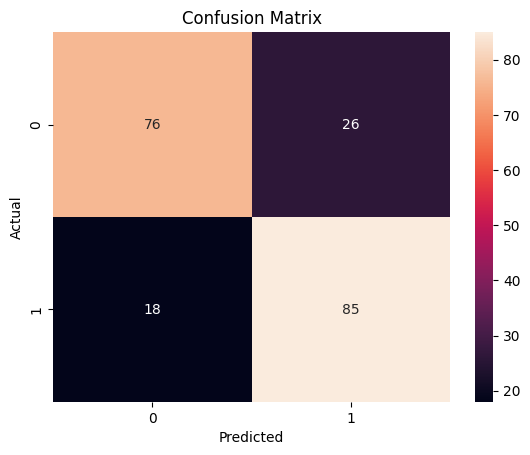

In [37]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Decision Tree model


In [38]:
dt_model=DecisionTreeClassifier(max_depth=5)
dt_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [39]:
#  check score of the model 
dt_model.score(X_train,y_train)*100,dt_model.score(X_test,y_test)*100

(93.04878048780488, 84.39024390243902)

In [40]:
y_pred_dt=dt_model.predict(X_test)

In [41]:
print("Decision Tree")
accuracy = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", accuracy)

Decision Tree
Accuracy: 0.8439024390243902


## Random forest Model

In [42]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)


RandomForestClassifier(random_state=42)

In [43]:
y_pred_rf=rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy)

Accuracy: 0.9853658536585366


[[102   0]
 [  3 100]]


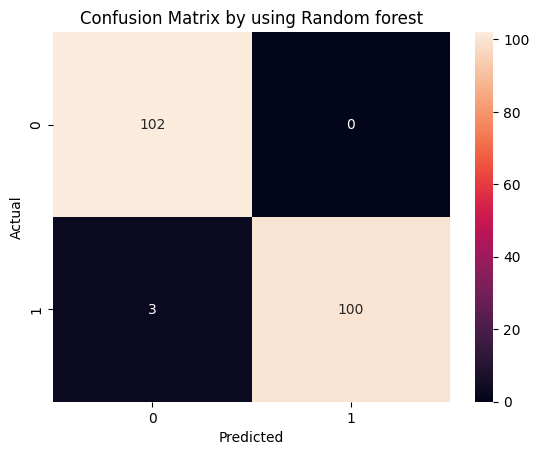

In [44]:
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix by using Random forest")
plt.show()

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print('AUC Score:',auc_score)

AUC Score: 0.9991433466590519


In [46]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



## Features importance 

In [47]:
import pandas as pd

importance = rf.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance*100
}).sort_values(by="Importance", ascending=False)

imp_df.head(10)

,Feature,Importance
10,thalassemia,15.161482
2,chest_pain_type,13.971431
9,vessels_colored_by_flourosopy,12.491101
5,Max_heart_rate,11.604607
7,oldpeak,11.396265
0,age,8.793159
4,cholestoral,8.225312
3,resting_blood_pressure,7.313928
6,exercise_induced_angina,4.732503
8,slope,3.991464
